## Лабораторная работа 1

## “Сбор, визуализация и анализ данных по графу”

# Сбор данных из arxiv


## Загрузка через api

In [1]:
%%capture
!pip install feedparser tqdm

In [2]:
import feedparser
import urllib.request as libreq
import pandas as pd
from tqdm import tqdm

In [3]:
def arxiv_request_url(search="cat:cs.SE", start=0, limit=500):
    return f"http://export.arxiv.org/api/query?search_query={search}&start={start}&max_results={limit}"


def get_articles():
    url = arxiv_request_url()
    with libreq.urlopen(url) as response:
        response_data = response.read()

    feed = feedparser.parse(response_data)
    results = []

    for entry in tqdm(feed.entries):
        id = entry.get('id')
        title = entry.get('title')
        authors = entry.get('authors', [])
        authors_str = ', '.join([author.name for author in authors]) if authors else None
        summary = entry.get('summary')

        results.append({
            'id': id,
            'title': title,
            'authors': authors_str,
            'abstract': summary,
        })

    return results

In [4]:
articles = get_articles()
print()
print(f"Собрано {len(articles)} статей. Из них уникальных по id: {len(set([a['id'] for a in articles]))}")

100%|██████████| 500/500 [00:00<00:00, 154931.44it/s]


Собрано 500 статей. Из них уникальных по id: 500


In [5]:
df_articles = pd.DataFrame(articles)
df_articles.drop_duplicates(subset='id', inplace=True)

print(f"Итоговое количество уникальных публикаций: {len(df_articles)}")
df_articles.head()

Итоговое количество уникальных публикаций: 500


,id,title,authors,abstract
0,http://arxiv.org/abs/cs/9810022v1,Broy-Lamport Specification Problem: A Gurevich...,James K. Huggins,We apply the Gurevich Abstract State Machine m...
1,http://arxiv.org/abs/cs/9810023v1,Equivalence is in the Eye of the Beholder,"Yuri Gurevich, James K. Huggins","In a recent provocative paper, Lamport points ..."
2,http://arxiv.org/abs/cs/9810024v1,Evolving Algebras and Partial Evaluation,"Yuri Gurevich, James K. Huggins",We describe an automated partial evaluator for...
3,http://arxiv.org/abs/cs/9810025v1,An Offline Partial Evaluator for Evolving Alge...,James K. Huggins,We describe the architecture of an evolving al...
4,http://arxiv.org/abs/cs/9810026v1,The Railroad Crossing Problem: An Experiment w...,"Yuri Gurevich, James K. Huggins",We give an evolving algebra solution for the w...


In [6]:
print(f"Количество уникальных авторов: {df_articles['authors'].nunique()}")

Количество уникальных авторов: 446


## Предобработка данных

In [7]:
%%capture
!pip install nltk
!pip install -U spacy --user

In [8]:
import nltk
import spacy
import string

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Скачиваем необходимые ресурсы NLTK
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# Загружаем английскую модель spaCy https://spacy.io/models/en
nlp = spacy.load("en_core_web_sm")

# Стоп-слова и пунктуация
stop_words = set(stopwords.words('english'))
punctuation = set(string.punctuation)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Дмитрий\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Дмитрий\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Дмитрий\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
def preprocess_text(title, abstract, debug=False):
    """
    Обрабатывает title + abstract:
    1. Токенизация
    2. Удаление стоп-слов и пунктуации
    3. Лемматизация (spaCy)
    """
    text = (title or "") + " " + (abstract or "")

    # --- 1. Токенизация ---
    tokens = word_tokenize(text.lower())  # приводим к нижнему регистру
    if debug:
        print(tokens)

    # --- 2. Удаление стоп-слов и пунктуации ---
    tokens = [t for t in tokens if t not in stop_words and t not in punctuation]
    if debug:
        print(tokens)

    # --- 3. Лемматизация (через spaCy) ---
    doc = nlp(" ".join(tokens))
    lemmas = [token.lemma_ for token in doc if token.lemma_ != "-PRON-" and token.lemma_ not in punctuation]

    return " ".join(lemmas)

In [10]:
test_preprocess = df_articles.iloc[0]
preprocess_text(test_preprocess['title'], test_preprocess['abstract'], debug=True)

['broy-lamport', 'specification', 'problem', ':', 'a', 'gurevich', 'abstract', 'state', 'machine', 'solution', 'we', 'apply', 'the', 'gurevich', 'abstract', 'state', 'machine', 'methodology', 'to', 'a', 'benchmark', 'specification', 'problem', 'of', 'broy', 'and', 'lamport', '.']
['broy-lamport', 'specification', 'problem', 'gurevich', 'abstract', 'state', 'machine', 'solution', 'apply', 'gurevich', 'abstract', 'state', 'machine', 'methodology', 'benchmark', 'specification', 'problem', 'broy', 'lamport']


'broy lamport specification problem gurevich abstract state machine solution apply gurevich abstract state machine methodology benchmark specification problem broy lamport'

In [11]:
# Применим функцию к каждому ряду
df_articles['text'] = df_articles.apply(
    lambda row: preprocess_text(row['title'], row['abstract']), axis=1
)

In [12]:
df_articles[['title', 'abstract', 'text']].head()

,title,abstract,text
0,Broy-Lamport Specification Problem: A Gurevich...,We apply the Gurevich Abstract State Machine m...,broy lamport specification problem gurevich ab...
1,Equivalence is in the Eye of the Beholder,"In a recent provocative paper, Lamport points ...",equivalence eye beholder recent provocative pa...
2,Evolving Algebras and Partial Evaluation,We describe an automated partial evaluator for...,evolve algebras partial evaluation describe au...
3,An Offline Partial Evaluator for Evolving Alge...,We describe the architecture of an evolving al...,offline partial evaluator evolve algebra descr...
4,The Railroad Crossing Problem: An Experiment w...,We give an evolving algebra solution for the w...,railroad crossing problem experiment instantan...


## Проверка и анализ собранных данных

In [13]:
# Проверим наличие пустых значений
print("Количество пропусков по колонкам:")
print(df_articles[['title', 'authors', 'text']].isna().sum())

# Проверим, есть ли строки с пустыми значениями
missing_rows = df_articles[df_articles[['title', 'authors', 'text']].isna().any(axis=1)]
print("Число строк с пропусками:", len(missing_rows))

Количество пропусков по колонкам:
title      0
authors    0
text       0
dtype: int64
Число строк с пропусками: 0


count    500.000000
mean       2.486000
std        1.419095
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max       10.000000
Name: n_authors, dtype: float64


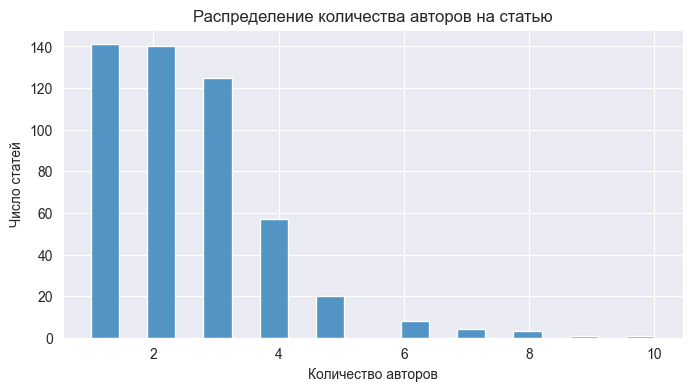

In [14]:
# Добавим колонку с количеством авторов
df_articles['n_authors'] = df_articles['authors'].apply(lambda x: len(str(x).split(",")))

# Статистика по авторам
print(df_articles['n_authors'].describe())

# Визуализация распределения
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.histplot(df_articles['n_authors'], bins=20, kde=False)
plt.title("Распределение количества авторов на статью")
plt.xlabel("Количество авторов")
plt.ylabel("Число статей")
plt.show()

        len_title  len_abstract    len_text
count  500.000000     500.00000  500.000000
mean     8.636000     125.29000   84.306000
std      3.480191      54.49765   35.130452
min      2.000000       5.00000    6.000000
25%      6.000000      86.00000   59.750000
50%      8.000000     124.50000   83.000000
75%     10.000000     159.25000  105.000000
max     26.000000     302.00000  201.000000


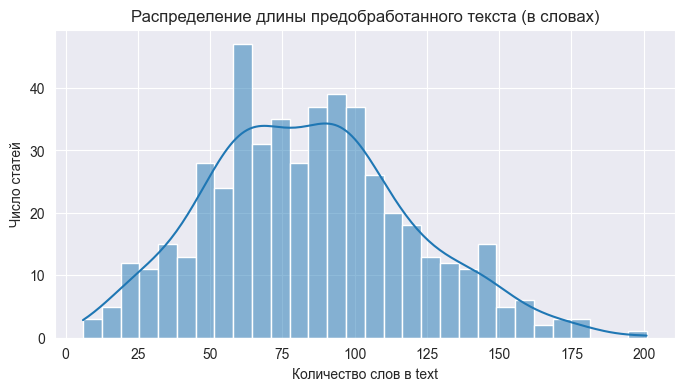

In [15]:
# Длина в словах (title, abstract, text)
df_articles['len_title'] = df_articles['title'].apply(lambda x: len(str(x).split()))
df_articles['len_abstract'] = df_articles['abstract'].apply(lambda x: len(str(x).split()))
df_articles['len_text'] = df_articles['text'].apply(lambda x: len(str(x).split()))

print(df_articles[['len_title', 'len_abstract', 'len_text']].describe())

# Визуализация распределения длины text
plt.figure(figsize=(8, 4))
sns.histplot(df_articles['len_text'], bins=30, kde=True)
plt.title("Распределение длины предобработанного текста (в словах)")
plt.xlabel("Количество слов в text")
plt.ylabel("Число статей")
plt.show()

Топ-20 слов:
 [('software', 783), ('system', 679), ('model', 555), ('use', 500), ('base', 353), ('paper', 351), ('process', 341), ('development', 315), ('approach', 292), ('design', 275), ('application', 268), ('method', 258), ('tool', 239), ('component', 237), ('present', 215), ('service', 212), ('requirement', 210), ('analysis', 201), ('code', 189), ('propose', 185)]


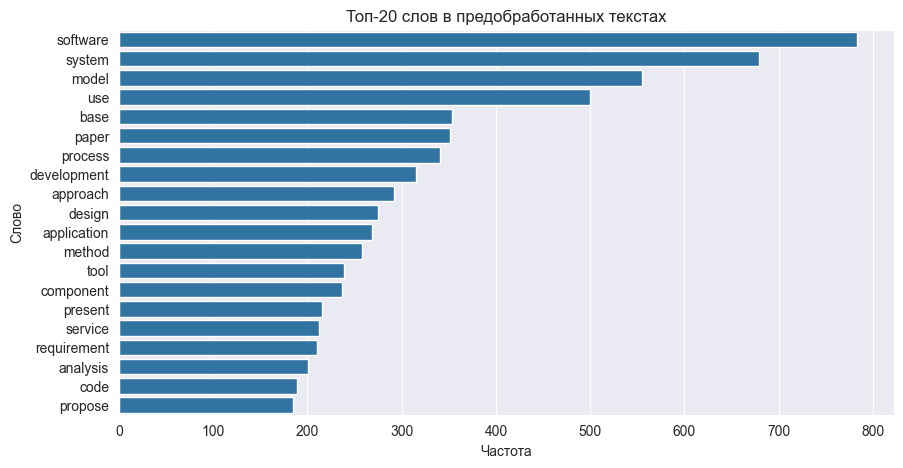

In [16]:
from collections import Counter

# Разобьём все тексты на слова
all_tokens = " ".join(df_articles['text']).split()
word_counts = Counter(all_tokens)

# Топ-20 слов
top_words = word_counts.most_common(20)
print("Топ-20 слов:\n", top_words)

# Визуализация
words, counts = zip(*top_words)
plt.figure(figsize=(10, 5))
sns.barplot(x=list(counts), y=list(words))
plt.title("Топ-20 слов в предобработанных текстах")
plt.xlabel("Частота")
plt.ylabel("Слово")
plt.show()

**Что в итоге получили:**
- Проверили, что в данных нет пропусков (все статьи имеют title, authors, text).
- Видим распределение количества авторов: чаще всего у статьи 1–3 автора.
- Распределение длин предобработанного текста похоже на нормальное.
- Топ слов выглядит адекватно и подходит под выбранную тематику (Software Engineering).


## Сохранение результата

In [17]:
# Сохраняем в CSV
output_path = "articles_preprocessed.csv"
df_articles.to_csv(output_path, index=False)

print(f"Файл сохранён: {output_path}")
print("Размер:", df_articles.shape)

Файл сохранён: articles_preprocessed.csv
Размер: (500, 9)


In [18]:
df_check = pd.read_csv(output_path)
print("Прочитано строк:", len(df_check))
df_check[['title', 'text']].head(5)

Прочитано строк: 500


,title,text
0,Broy-Lamport Specification Problem: A Gurevich...,broy lamport specification problem gurevich ab...
1,Equivalence is in the Eye of the Beholder,equivalence eye beholder recent provocative pa...
2,Evolving Algebras and Partial Evaluation,evolve algebras partial evaluation describe au...
3,An Offline Partial Evaluator for Evolving Alge...,offline partial evaluator evolve algebra descr...
4,The Railroad Crossing Problem: An Experiment w...,railroad crossing problem experiment instantan...


# Выделение ключевых слов

In [19]:
%%capture
!pip install transformers torch --user

In [20]:
from transformers import pipeline
import torch

In [21]:
model_name = "ilsilfverskiold/tech-keywords-extractor"

# Проверим, доступна ли CUDA, и установим device
device = 0 if torch.cuda.is_available() else -1
print(f"Используемое устройство: {'CUDA' if device == 0 else 'CPU'}")

# Создание пайплайна для генерации текста (извлечения ключевых слов)
try:
    keyword_extractor = pipeline(
        "text2text-generation",  # Используем генерацию текста
        model=model_name,
        tokenizer=model_name,
        device=device,
        batch_size=8,
    )
    print("Модель успешно загружена как генеративная.")
except Exception as e:
    print(f"Ошибка при загрузке модели: {e}")
    keyword_extractor = None

Используемое устройство: CUDA


Device set to use cuda:0


Модель успешно загружена как генеративная.


In [22]:
def extract_keywords(text, extractor):
    """
    Извлекает ключевые слова из текста с помощью генеративной модели.
    """
    if extractor is None:
        return []
    keywords = extractor(text)[0]["generated_text"].split(", ")
    return [keyword.lower() for keyword in keywords]

In [23]:
# Проверим, как работает модель на одном примере
test_text = df_articles.iloc[0]['text']

print(f"Тестовый пример: {test_text}")

# Попробуем извлечь ключевые слова из тестового названия
if keyword_extractor is not None:
    print("\nИзвлечение ключевых слов...")
    test_keywords = extract_keywords(test_text, keyword_extractor)
    print(f"Ключевые слова: {test_keywords}")
else:
    print("Модель не была загружена. Пропускаем тестирование.")

Тестовый пример: broy lamport specification problem gurevich abstract state machine solution apply gurevich abstract state machine methodology benchmark specification problem broy lamport

Извлечение ключевых слов...
Ключевые слова: ['broy lamport', 'gurevich', 'abstract state machine', 'benchmark']


In [24]:
print("Начинаем извлечение ключевых слов...")
# Применяем функцию с отображением прогресса
keywords_list = []
for text in tqdm(df_articles['text'], desc="Извлечение ключевых слов"):
    keywords = extract_keywords(text, keyword_extractor)
    keywords_list.append(keywords)

df_articles['keywords'] = keywords_list

Начинаем извлечение ключевых слов...


Извлечение ключевых слов: 100%|██████████| 500/500 [03:10<00:00,  2.62it/s]


In [25]:
# Посмотрим на результаты
print(f"Среднее количество ключевых слов на статью: {df_articles['keywords'].apply(len).mean():.2f}")
df_articles[['title', 'keywords']].head()

Среднее количество ключевых слов на статью: 4.09


,title,keywords
0,Broy-Lamport Specification Problem: A Gurevich...,"[broy lamport, gurevich, abstract state machin..."
1,Equivalence is in the Eye of the Beholder,"[equivalence, algorithm, lamport point insubst..."
2,Evolving Algebras and Partial Evaluation,"[evolve algebras, partial evaluation, universi..."
3,An Offline Partial Evaluator for Evolving Alge...,"[offline partial evaluator, evolve algebra, ar..."
4,The Railroad Crossing Problem: An Experiment w...,"[railroad crossing problem, algebra, agent fir..."


# Построение и анализ графа ключевых слов


In [26]:
import networkx as nx
import numpy as np
from itertools import combinations
from collections import Counter

# Создаём граф
G = nx.Graph()

for keywords_list in df_articles['keywords']:
    keywords = [kw.strip().lower() for kw in keywords_list]

    # добавляем узлы
    G.add_nodes_from(keywords)

    # добавляем рёбра (все пары слов из одной статьи)
    for w1, w2 in combinations(sorted(set(keywords)), 2):
        if G.has_edge(w1, w2):
            G[w1][w2]['weight'] += 1
        else:
            G.add_edge(w1, w2, weight=1)

In [27]:
print(f"Число узлов (уникальных ключевых слов): {G.number_of_nodes()}")
print(f"Число рёбер: {G.number_of_edges()}")
print("Плотность графа:", nx.density(G))
print("Средняя степень:", sum(dict(G.degree()).values()) / G.number_of_nodes())
print("Число компонент:", nx.number_connected_components(G))

Число узлов (уникальных ключевых слов): 1648
Число рёбер: 3471
Плотность графа: 0.00255760694643394
Средняя степень: 4.212378640776699
Число компонент: 175


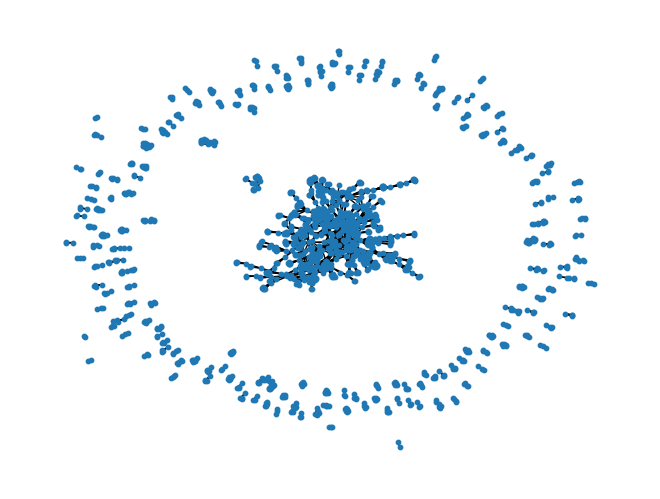

In [28]:
nx.draw(G, with_labels=False, font_weight='bold', node_size=10)

In [29]:
communities = nx.community.louvain_communities(G, weight="weight")
communities_sizes = [len(c) for c in communities]

print(f"Количество кластеров: {len(communities)}")
print(f"Модулярность: {nx.community.modularity(G, communities)}")

print()
print(f"Размеры кластеров: {sorted(communities_sizes, reverse=True)[:10]}")
print(f"Средний размер кластера: {np.mean(communities_sizes):.2f}")
print(f"Медианный размер кластера: {np.median(communities_sizes):.2f}")
print(f"Максимальный размер кластера: {max(communities_sizes)}")
print(f"Минимальный размер кластера: {min(communities_sizes)}")

Количество кластеров: 193
Модулярность: 0.9309791350534496

Размеры кластеров: [86, 81, 77, 58, 57, 57, 49, 47, 46, 43]
Средний размер кластера: 8.54
Медианный размер кластера: 4.00
Максимальный размер кластера: 86
Минимальный размер кластера: 2


Модулярность 0.9 означает, что внутри сообществ узлы сильно связаны, а между разными сообществами связей почти нет

In [30]:
cluster_summary = []

for i, comm in enumerate(communities, 1):
    # сортируем слова по степени внутри графа
    sorted_words = sorted(list(comm), key=lambda x: G.degree(x), reverse=True)
    top_words = sorted_words[:10]
    cluster_summary.append({
        "cluster": i,
        "size": len(comm),
        "top_keywords": ", ".join(top_words)
    })

df_clusters = pd.DataFrame(cluster_summary)
df_clusters.sort_values(by="size", ascending=False).head(10)

,cluster,size,top_keywords
87,88,86,"web service, modularity, eclipse, javascript, ..."
169,170,81,"software development, architecture, software q..."
45,46,77,"software engineering, psf, natural language pr..."
86,87,58,"uml, software architecture, workflow, formal s..."
62,63,57,"microsoft, spreadsheet, excel, c++, debian, li..."
25,26,57,"computer control system, python, debugging, so..."
119,120,49,"java, virtual machine, java environment, java ..."
184,185,47,"system development, mda, system design, model ..."
36,37,46,"open source, algorithms, automaton, uppaal, tr..."
51,52,43,"software component, verification, control syst..."


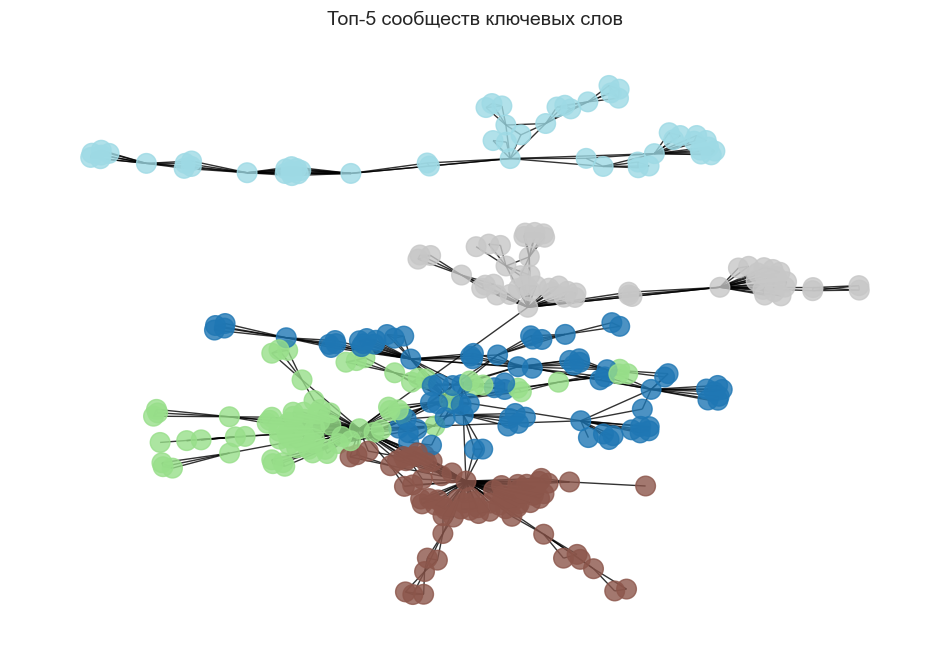

In [31]:
import matplotlib.pyplot as plt

# Берем топ-5 по размеру
sorted_communities = sorted(communities, key=len, reverse=True)[:5]
top_nodes = set().union(*sorted_communities)

# Строим подграф
H = G.subgraph(top_nodes)

# Словарь: узел → номер сообщества
node2comm = {}
for i, comm in enumerate(sorted_communities):
    for node in comm:
        node2comm[node] = i

# Layout для подграфа (без фиксирования позиций)
pos = nx.spring_layout(H, iterations=50)

plt.figure(figsize=(12, 8))

# Раскрашиваем узлы по сообществам
colors = [node2comm[node] for node in H.nodes()]

nx.draw_networkx(
    H,
    pos,
    node_color=colors,
    node_size=200,  # одинаковый размер для всех
    with_labels=False,
    font_size=8,
    cmap=plt.cm.tab20,
    alpha=0.8
)

plt.title("Топ-5 сообществ ключевых слов", fontsize=14)
plt.axis("off")
plt.show()


# Анализ ключевых слов по центральности

Для графа ключевых слов были рассчитаны четыре вида центральности:  
- **Degree centrality** (степень, количество связей),  
- **Betweenness centrality** (посредничество, «мосты» между кластерами),  
- **Eigenvector centrality** (влияние, связь с важными узлами),  
- **Closeness centrality** (близость к другим узлам).  

Ниже приведены топ-10 ключевых слов по каждой метрике и интерпретация результатов.

In [32]:
# Вычисляем degree centrality
degree_centrality = nx.degree_centrality(G)

# Сортируем по убыванию и выводим топ-10
sorted_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)
print("Топ-10 ключевых слов по Degree Centrality:")
for i, (keyword, score) in enumerate(sorted_degree[:10], 1):
    print(f"{i:2d}. {keyword:<30} {score:.4f}")

Топ-10 ключевых слов по Degree Centrality:
 1. software development           0.0528
 2. software engineering           0.0492
 3. java                           0.0334
 4. open source                    0.0285
 5. uml                            0.0200
 6. web service                    0.0164
 7. software architecture          0.0158
 8. software component             0.0158
 9. system development             0.0152
10. software system                0.0128


### Degree Centrality

- **Что измеряет:** доля всех возможных связей.  
- **Результаты:** лидируют *software development* (0.052) и *software engineering* (0.049).  
- Для большого графа значение 0.05 можно считать достаточно высоким показателем. Так как общее число узлов 1600 то, чтобы получить значение 0.05 у узла должно быть 80 связей



In [33]:
print("Вычисляем betweenness centrality...")
betweenness_centrality = nx.betweenness_centrality(G, weight='weight')

# Сортируем по убыванию и выводим топ-10
sorted_betweenness = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)
print("\nТоп-10 ключевых слов по Betweenness Centrality:")
for i, (keyword, score) in enumerate(sorted_betweenness[:10], 1):
    print(f"{i:2d}. {keyword:<30} {score:.4f}")

Вычисляем betweenness centrality...

Топ-10 ключевых слов по Betweenness Centrality:
 1. software development           0.0902
 2. java                           0.0708
 3. software engineering           0.0548
 4. open source                    0.0488
 5. uml                            0.0383
 6. reverse engineering            0.0382
 7. debugging                      0.0322
 8. software component             0.0258
 9. modularity                     0.0225
10. web service                    0.0202


### Betweenness Centrality

- **Что измеряет:** насколько часто узел лежит на кратчайших путях между другими узлами.  
- **Результаты:** лидируют *software development* (0.1019), *software engineering* (0.09), *java* (0.07).  
- Значения выше 0.05 указывают на значимую роль узла как «связующего».  

**Интерпретация:**  
Эти ключевые слова соединяют разные тематические направления (и возможно будут единственным связующим звеном между различными кластерами). Например *software development* и *software engineering*, которые в целом соответствуют исследуемой категории и будут встречаться в даже в различных узкоспециализированных статьях.


In [34]:
print("Вычисляем eigenvector centrality...")
eigenvector_centrality = nx.eigenvector_centrality(G, weight='weight', max_iter=1000)

# Сортируем по убыванию и выводим топ-10
sorted_eigenvector = sorted(eigenvector_centrality.items(), key=lambda x: x[1], reverse=True)
print("Топ-10 ключевых слов по Eigenvector Centrality:")
for i, (keyword, score) in enumerate(sorted_eigenvector[:10], 1):
    print(f"{i:2d}. {keyword:<30} {score:.4f}")

Вычисляем eigenvector centrality...
Топ-10 ключевых слов по Eigenvector Centrality:
 1. software development           0.5289
 2. software engineering           0.3969
 3. java                           0.2183
 4. open source                    0.2139
 5. psf                            0.1281
 6. process algebra                0.1261
 7. reverse engineering            0.1106
 8. system development             0.1081
 9. system design                  0.1063
10. architecture                   0.1023


### Eigenvector Centrality

- **Что измеряет:** влияние узла — насколько он связан с другими важными узлами.  

**Интерпретация:**  
Эти слова образуют «ядро» графа ключевых слов. Значения выглядят логично, потому что фундаментальные понятия (*software development* и *software engineering*) имеют наивысшие значения. 

In [35]:
# Вычисляем closeness centrality
closeness_centrality = nx.closeness_centrality(G, distance='weight')

# Сортируем по убыванию и выводим топ-10
sorted_closeness = sorted(closeness_centrality.items(), key=lambda x: x[1], reverse=True)
print("Топ-10 ключевых слов по Closeness Centrality:")
for i, (keyword, score) in enumerate(sorted_closeness[:10], 1):
    print(f"{i:2d}. {keyword:<30} {score:.4f}")

Топ-10 ключевых слов по Closeness Centrality:
 1. software development           0.1537
 2. reverse engineering            0.1532
 3. java                           0.1475
 4. uml                            0.1417
 5. modularity                     0.1386
 6. software engineering           0.1385
 7. crosscut concern               0.1384
 8. open source                    0.1373
 9. system design                  0.1361
10. eclipse                        0.1355


### Closeness Centrality

- **Что измеряет:** среднее расстояние от узла до всех остальных. Чем выше, тем быстрее можно достичь все остальные узлы из текущего.  
- **Результаты:** лидирует *reverse engineering* (0.1594), затем *software development* (0.15) и *system design* (0.15).  

**Интерпретация:**  
Ключевые слова с высокой близостью расположены в центре всей сети. *reverse engineering* обогнал даже базовые понятия — это говорит о его универсальности и применимости во многих направлениях.


In [36]:
# Создаем сводную таблицу топ-15 ключевых слов по каждой метрике
import pandas as pd

# Берем топ-15 по каждой метрике
top_degree = [kw for kw, _ in sorted_degree[:15]]
top_betweenness = [kw for kw, _ in sorted_betweenness[:15]]
top_eigenvector = [kw for kw, _ in sorted_eigenvector[:15]] if eigenvector_centrality else []
top_closeness = [kw for kw, _ in sorted_closeness[:15]]

# Создаем множество всех топовых ключевых слов
all_top_keywords = set(top_degree + top_betweenness + top_eigenvector + top_closeness)

# Создаем DataFrame для сравнения
centrality_comparison = []
for keyword in all_top_keywords:
    row = {
        'Keyword': keyword,
        'Degree': degree_centrality.get(keyword, 0),
        'Betweenness': betweenness_centrality.get(keyword, 0),
        'Eigenvector': eigenvector_centrality.get(keyword, 0) if eigenvector_centrality else 0,
        'Closeness': closeness_centrality.get(keyword, 0)
    }
    centrality_comparison.append(row)

df_centrality = pd.DataFrame(centrality_comparison)

# Сортируем по degree centrality (можно выбрать другую метрику)
df_centrality = df_centrality.sort_values('Degree', ascending=False).reset_index(drop=True)

# Отображаем результаты
print("Сводная таблица топ ключевых слов по разным мерам центральности:")
df_centrality.head(15)

Сводная таблица топ ключевых слов по разным мерам центральности:


,Keyword,Degree,Betweenness,Eigenvector,Closeness
0,software development,0.052823,0.090239,0.528880,0.153746
1,software engineering,0.049180,0.054782,0.396943,0.138461
2,java,0.033394,0.070753,0.218336,0.147534
3,open source,0.028537,0.048847,0.213915,0.137335
4,uml,0.020036,0.038276,0.078352,0.141655
5,web service,0.016393,0.020163,0.016005,0.124739
6,software component,0.015786,0.025795,0.025498,0.124089
7,software architecture,0.015786,0.017418,0.009797,0.118225
8,system development,0.015179,0.015499,0.108123,0.130903
9,software system,0.012750,0.012587,0.012294,0.122551


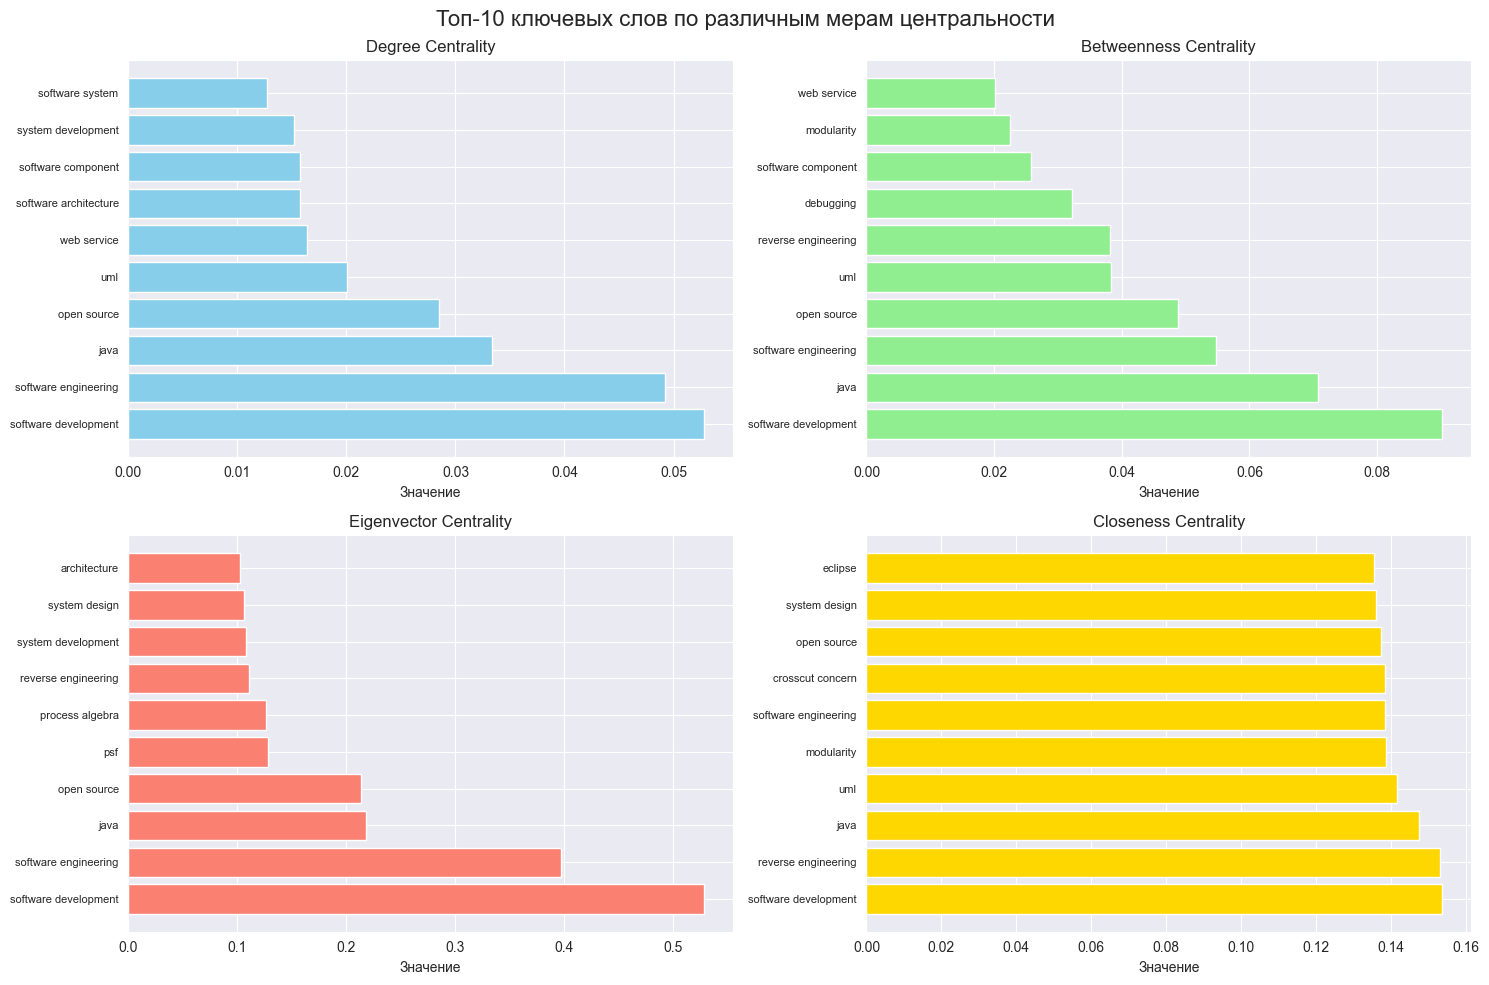

In [37]:
# Визуализируем топ-10 ключевых слов по каждой метрике центральности
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Топ-10 ключевых слов по различным мерам центральности', fontsize=16)

# Топ-10 по Degree Centrality
top_10_degree = sorted_degree[:10]
keywords_degree = [kw for kw, _ in top_10_degree]
scores_degree = [score for _, score in top_10_degree]
axes[0, 0].barh(keywords_degree, scores_degree, color='skyblue')
axes[0, 0].set_title('Degree Centrality')
axes[0, 0].set_xlabel('Значение')

# Топ-10 по Betweenness Centrality
top_10_betweenness = sorted_betweenness[:10]
keywords_betweenness = [kw for kw, _ in top_10_betweenness]
scores_betweenness = [score for _, score in top_10_betweenness]
axes[0, 1].barh(keywords_betweenness, scores_betweenness, color='lightgreen')
axes[0, 1].set_title('Betweenness Centrality')
axes[0, 1].set_xlabel('Значение')

# Топ-10 по Eigenvector Centrality
if eigenvector_centrality:
    top_10_eigenvector = sorted_eigenvector[:10]
    keywords_eigenvector = [kw for kw, _ in top_10_eigenvector]
    scores_eigenvector = [score for _, score in top_10_eigenvector]
    axes[1, 0].barh(keywords_eigenvector, scores_eigenvector, color='salmon')
    axes[1, 0].set_title('Eigenvector Centrality')
    axes[1, 0].set_xlabel('Значение')

# Топ-10 по Closeness Centrality
top_10_closeness = sorted_closeness[:10]
keywords_closeness = [kw for kw, _ in top_10_closeness]
scores_closeness = [score for _, score in top_10_closeness]
axes[1, 1].barh(keywords_closeness, scores_closeness, color='gold')
axes[1, 1].set_title('Closeness Centrality')
axes[1, 1].set_xlabel('Значение')

# Поворачиваем подписи для лучшей читаемости
for ax in axes.flat:
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

### Итоговый вывод по ключевым словам

- **Software development** и **software engineering** — системообразующие ключевые слова, лидирующие по всем метрикам.  
- **Java** и **open source** играют важную роль как посредники и часто встречающиеся термины.  
- **Reverse engineering** выделяется своей центральной позицией в метриках betweenness и closeness, что подчёркивает его роль «моста» между разными областями.  
- Дополнительные значимые понятия (*UML*, *object orient*, *reusability*, *automation*) отражают фундаментальные направления исследований в Software Engineering.  

Таким образом, анализ центральностей показывает, что структура области хорошо организована: есть выраженное ядро из базовых понятий и несколько опорных тем, соединяющих разные направления исследований.


# Граф публикаций

In [38]:
# --- Построение графа ---
publicationGraph = nx.Graph()

# Добавляем узлы (названия публикаций)
for _, row in df_articles.iterrows():
    publicationGraph.add_node(row['id'], title=row['title'], authors=row['authors'], keywords=row['keywords'])

# Добавляем рёбра на основе общих ключевых слов
for i in range(len(df_articles)):
    for j in range(i + 1, len(df_articles)):
        k1, k2 = set(df_articles.iloc[i]['keywords']), set(df_articles.iloc[j]['keywords'])
        common = k1 & k2
        if common:
            publicationGraph.add_edge(df_articles.iloc[i]['id'], df_articles.iloc[j]['id'], weight=len(common))

In [39]:
# --- Функция: ближайшие публикации по прямым рёбрам ---
def find_closest_neighbors(G, source, top_n=5):
    if source not in G:
        raise ValueError(f"Узел {source} не найден в графе")

    neighbors = []
    for nbr, edata in G[source].items():
        w = edata.get("weight", 0)
        neighbors.append((nbr, w))

    # сортировка по убыванию веса
    neighbors.sort(key=lambda x: (-x[1], x[0]))

    result = []
    for node, w in neighbors[:top_n]:
        result.append({
            "id": node,
            "title": G.nodes[node].get("title"),
            "authors": G.nodes[node].get("authors"),
            "weight": w,
            "shared_keywords": list(set(G.nodes[source]["keywords"]) & set(G.nodes[node]["keywords"]))
        })
    return result

In [40]:
# --- Функция: ближайшие публикации по кратчайшему пути ---
def find_closest_shortest_path(G, source, top_n=5):
    if source not in G:
        raise ValueError(f"Узел {source} не найден в графе")

    def weight_func(u, v, attr):
        w = attr.get("weight", 0)
        return 1.0 / w if w > 0 else float("inf")

    lengths = nx.single_source_dijkstra_path_length(G, source, weight=weight_func)

    result = []
    for node, dist in lengths.items():
        if node == source:
            continue
        score = 1.0 / dist if dist > 0 else 0.0
        path = nx.shortest_path(G, source, node, weight=weight_func)
        result.append({
            "id": node,
            "title": G.nodes[node].get("title"),
            "authors": G.nodes[node].get("authors"),
            "distance": dist,
            "score": score,
            "path": path,
            "shared_keywords": list(set(G.nodes[source]["keywords"]) & set(G.nodes[node]["keywords"]))
        })

    # сортируем по возрастанию расстояния
    result.sort(key=lambda x: (x["distance"], x["id"]))
    return result[:top_n]

In [48]:
source = df_articles.iloc[152]
print(source["id"], source["title"], '|', source["authors"], '|', source["keywords"], '\n')

print("=== Weighted Neighbors ===")
for r in find_closest_neighbors(publicationGraph, source["id"], top_n=3):
    print(r)

print("\n=== Shortest Path ===")
for r in find_closest_shortest_path(publicationGraph, source["id"], top_n=3):
    print(r)

http://arxiv.org/abs/0801.4774v1 Source Code Protection for Applications Written in Microsoft Excel and
  Google Spreadsheet | Thomas A. Grossman | ['source code protection', 'microsoft', 'excel', 'google', 'spreadsheet'] 

=== Weighted Neighbors ===
{'id': 'http://arxiv.org/abs/1008.4174v1', 'title': 'Spreadsheets Grow Up: Three Spreadsheet Engineering Methodologies for\n  Large Financial Planning Models', 'authors': 'Thomas A. Grossman, Ozgur Ozluk', 'weight': 3, 'shared_keywords': ['spreadsheet', 'excel', 'microsoft']}
{'id': 'http://arxiv.org/abs/1009.2797v1', 'title': 'What we understand is what we get: Assessment in Spreadsheets', 'authors': 'Andrea Kohlhase, Michael Kohlhase', 'weight': 2, 'shared_keywords': ['spreadsheet', 'excel']}
{'id': 'http://arxiv.org/abs/0802.3940v1', 'title': 'Spreadsheet Structure Discovery with Logic Programming', 'authors': 'Jocelyn Paine', 'weight': 1, 'shared_keywords': ['spreadsheet']}

=== Shortest Path ===
{'id': 'http://arxiv.org/abs/1008.4174v

# Визуализация

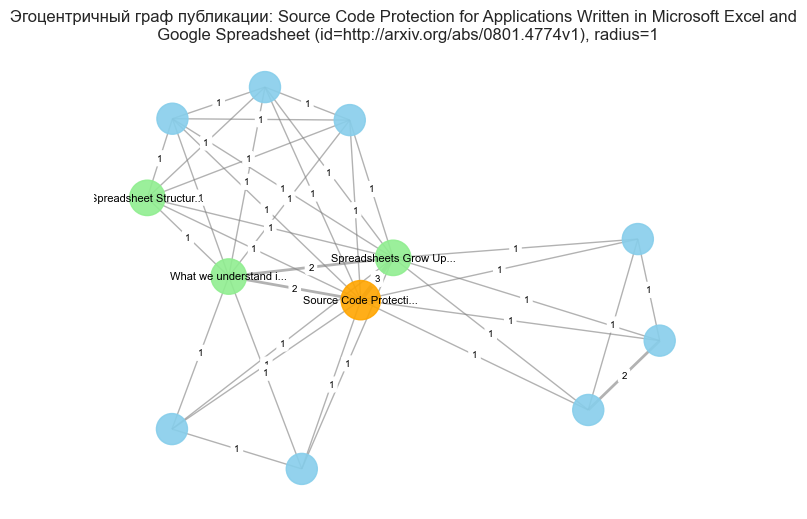

In [55]:
def draw_publication_ego_graph(G, source, radius=2, highlighted=None):
    if source not in G:
        raise ValueError(f"Узел {source} не найден в графе")

    ego = nx.ego_graph(G, source, radius=radius)
    pos = nx.spring_layout(ego, seed=42)

    # размеры и цвета узлов
    node_sizes = []
    node_colors = []
    for node in ego.nodes():
        if node == source:
            node_sizes.append(800)
            node_colors.append("orange")
        elif highlighted and node in highlighted:
            node_sizes.append(650)
            node_colors.append("lightgreen")
        else:
            node_sizes.append(500)
            node_colors.append("skyblue")

    # рёбра: толщина = вес
    edge_weights = [ego[u][v].get("weight", 1) for u, v in ego.edges()]

    # подписи весов рёбер
    edge_labels = {(u, v): f"{ego[u][v].get('weight', 1)}" for u, v in ego.edges()}

    def short_title(title):
        return title if len(title) <= 20 else f"{title[:20]}..."

    labels = {source: short_title(G.nodes[source].get("title", str(source)))}
    if highlighted:
        for n in highlighted:
            if n in ego.nodes():
                labels[n] = short_title(G.nodes[n].get("title", str(n)))

    # рисуем
    plt.figure(figsize=(8, 6))
    nx.draw_networkx_nodes(ego, pos, node_size=node_sizes, node_color=node_colors, alpha=0.9)
    nx.draw_networkx_edges(ego, pos, width=edge_weights, edge_color="gray", alpha=0.6)
    nx.draw_networkx_labels(ego, pos, labels=labels, font_size=8)
    nx.draw_networkx_edge_labels(ego, pos, edge_labels=edge_labels, font_size=7, rotate=False)

    plt.title(f"Эгоцентричный граф публикации: {G.nodes[source].get('title', '')} (id={source}), radius={radius}", fontsize=12)
    plt.axis("off")
    plt.show()


closest = find_closest_neighbors(publicationGraph, source["id"], top_n=3)
highlighted_ids = [item["id"] for item in closest]
draw_publication_ego_graph(publicationGraph, source["id"], radius=1, highlighted=highlighted_ids)